# COVID-19 Chatbot — development notebook

This notebook is where the retrieval system is **built and evaluated**: EDA, the data
pipeline, the BM25 baseline, the semantic retriever that replaces it, threshold tuning, and
the final measured result.

### The workflow contract (PRD §7.6)

> Reusable logic lives in `src/`. This notebook **imports** it and orchestrates.
> It must never keep its own copy of preprocessing, retrieval, or metric code.
> `src/api.py` imports the *same* modules.

One implementation, two consumers. That is what makes the numbers below the numbers the
app actually serves — the failure mode of the previous project, whose notebook trained a
BERT-QA model while its API served an unrelated DialoGPT.

If something here stabilizes, lift it into `src/` and import it back. Don't paste it.

---

**Contents**

| Section | Phase |
|---|---|
| 1. Setup | — |
| 2. Build the artifacts | 1 |
| 3. Corpus EDA | 1 |
| 4. Query & relevance EDA | 1 |
| 5. Split integrity | 1 |
| 6. BM25 baseline | 2 |
| 7. Semantic retriever + abstention | 3 |
| 8. Final evaluation on the test split | 3 |

Every reported number comes from the held-out **test** split via `src/evaluate.py`, with a
confidence interval where a comparison is being claimed.

## 1. Setup

In [1]:
from pathlib import Path
import sys

# Notebook lives in notebooks/, so the project root is one level up.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.dpi"] = 110

print("project root:", PROJECT_ROOT)

project root: C:\Users\DELL\Documents\COVID-19-CHAT-BOT


In [2]:
# Everything below is imported, never redefined (PRD §7.6).
from src import prep
from src.prep import DATA_DIR, RAW_DIR, SPLIT_RATIOS, classify_trust, normalize_text

print("imported from src.prep:", [n for n in ("build_kb", "build_qrels", "make_splits",
                                              "normalize_text", "classify_trust")])

imported from src.prep: ['build_kb', 'build_qrels', 'make_splits', 'normalize_text', 'classify_trust']


## 2. Build the artifacts

`src.prep.run()` is the same function `python -m src.prep` calls. Running it here
guarantees the notebook and the CLI produce identical artifacts.

In [3]:
if not (DATA_DIR / "kb.parquet").exists():
    from src import download
    download.fetch()
    prep.run()

kb = pd.read_parquet(DATA_DIR / "kb.parquet")
queries = pd.read_parquet(DATA_DIR / "queries.parquet")
qrels = pd.read_parquet(DATA_DIR / "qrels.parquet")
report = json.loads((DATA_DIR / "prep_report.json").read_text(encoding="utf-8"))

print(f"KB      {len(kb):>7,} entries")
print(f"queries {len(queries):>7,}")
print(f"qrels   {len(qrels):>7,}  ({int(qrels['relevant'].sum()):,} positive)")

KB        7,077 entries
queries   1,201
qrels    38,387  (7,833 positive)


### What preprocessing changed, and why

The prep report exists so nothing is removed silently. The two numbers that matter most:

- **`qrels_remapped`** — judgments pointing at a de-duplicated FAQ row, redirected onto the
  surviving copy instead of being dropped. Dropping them would delete real positives and
  **understate every metric** we go on to report.
- **`positives_lost` / `positives_merged`** — the full accounting. `src.prep` asserts
  `raw == final + lost + merged` and refuses to write artifacts if it doesn't balance.

In [4]:
pd.DataFrame(
    [
        ("raw FAQ rows",                 report["raw_faq_rows"]),
        ("dropped: no question",         len(report["dropped_missing_question"])),
        ("dropped: no answer",           len(report["dropped_missing_answer"])),
        ("duplicate groups collapsed",   report["duplicate_groups"]),
        ("dropped as duplicates",        len(report["dropped_duplicates"])),
        ("final KB rows",                report["kb_rows"]),
        ("",                             None),
        ("raw qrel rows",                report["raw_qrel_rows"]),
        ("dropped: query not in bank",   report["qrels_dropped_orphan_query"]),
        ("dropped: FAQ row unusable",    report["qrels_dropped_dangling_faq"]),
        ("REMAPPED onto surviving dup",  report["qrels_remapped"]),
        ("  of which positive",          report["qrels_remapped_positive"]),
        ("final qrel rows",              report["qrel_rows"]),
        ("",                             None),
        ("raw positives",                report["raw_positive_rows"]),
        ("  positives lost",             report["positives_lost"]),
        ("  positives merged",           report["positives_merged"]),
        ("  final positives",            report["positive_rows"]),
    ],
    columns=["step", "n"],
).fillna("").style.hide(axis="index")

step,n
raw FAQ rows,7117.000000
dropped: no question,1.000000
dropped: no answer,1.000000
duplicate groups collapsed,36.000000
dropped as duplicates,38.000000
final KB rows,7077.000000
,
raw qrel rows,39760.000000
dropped: query not in bank,1145.000000
dropped: FAQ row unusable,14.000000


In [5]:
raw_pos = report["raw_positive_rows"]
balanced = report["positive_rows"] + report["positives_lost"] + report["positives_merged"]
print(f"{raw_pos:,} raw positives = {report['positive_rows']:,} final "
      f"+ {report['positives_lost']:,} lost + {report['positives_merged']:,} merged "
      f"= {balanced:,}")
assert balanced == raw_pos
print("accounting balances")

7,856 raw positives = 7,833 final + 1 lost + 22 merged = 7,856
accounting balances


## 3. Corpus EDA

The knowledge base is both the **retrieval corpus and the served content** — the same set,
by design (PRD §6.2). Whatever is wrong with it is wrong with the product, so it's worth
looking at honestly.

In [6]:
kb.head(3)

,id,question,answer,source,url,trust
0,0,Does AHCCCS have a centralized resource for medical coding resources related to COVID-19?,"Yes, the AHCCCS Medical Coding Resources webpage includes a COVID-19 Medical Coding In...",AHCCCS,https://www.azahcccs.gov/AHCCCS/AboutUs/covid19FAQ.html,official
1,1,Are there billing codes available for COVID-19 testing outside of Centers for Disease ...,Yes. The Centers for Medicare & Medicaid Services (CMS) created a new Healthcare Commo...,AHCCCS,https://www.azahcccs.gov/AHCCCS/AboutUs/covid19FAQ.html,official
2,2,Will AHCCCS issue guidance regarding prior authorization expectations related to COVID...,Prior authorization is not permitted for COVID-19 testing or treatment.,AHCCCS,https://www.azahcccs.gov/AHCCCS/AboutUs/covid19FAQ.html,official


trust
official     3986
community    3091 

official: 56.3% of the corpus


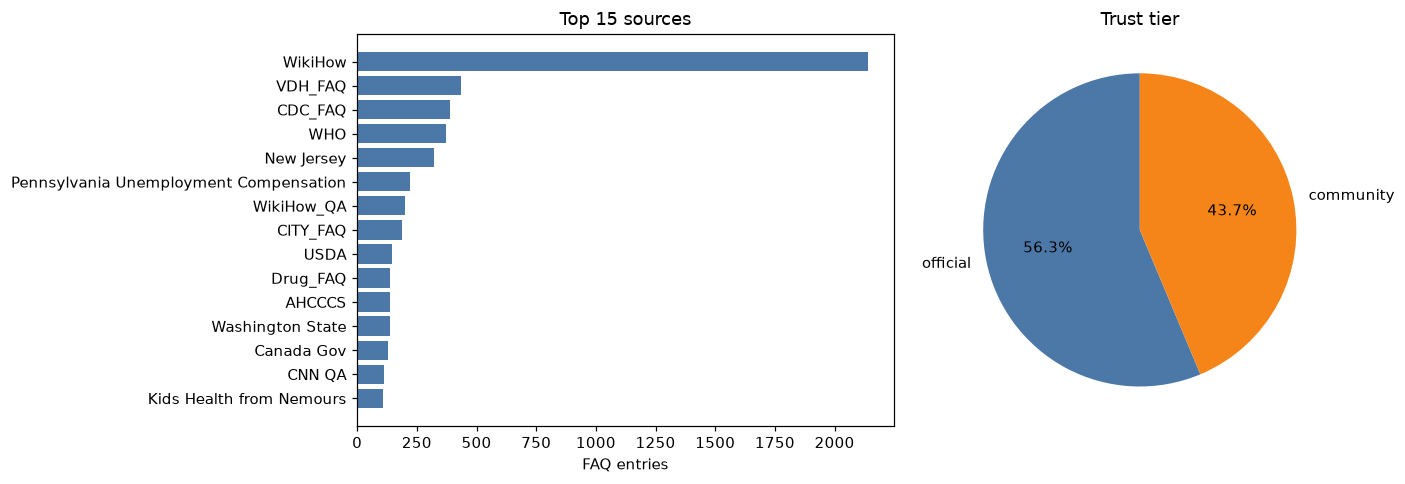

In [7]:
trust = kb["trust"].value_counts()
print(trust.to_string(), "\n")
print(f"official: {trust.get('official', 0) / len(kb):.1%} of the corpus")

top = kb["source"].value_counts().head(15)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].barh(top.index[::-1], top.values[::-1], color="#4C78A8")
ax[0].set_title("Top 15 sources"); ax[0].set_xlabel("FAQ entries")
ax[1].pie(trust.values, labels=trust.index, autopct="%1.1f%%",
          colors=["#4C78A8", "#F58518"], startangle=90)
ax[1].set_title("Trust tier")
plt.tight_layout(); plt.show()

**Observation.** WikiHow alone is ~30% of the corpus, and the community tier is a large
minority overall. That is the single most important quality fact about this dataset and it
drives three product decisions:

1. the response carries a `trust` field, so the UI can label provenance;
2. the disclaimer is unconditional, not just for community answers;
3. when duplicates are collapsed, the **official** copy survives (`src.prep` ranks by trust
   before id), so identical content is attributed to the better source.

A third `academic` tier — Harvard, JHU, Penn Med, AMA — is a defensible v2 refinement. PRD
§6.4 specifies two tiers, so this build keeps two.

,count,mean,std,min,25%,50%,75%,max
question_chars,7077.0,76.5,57.5,1.0,47.0,62.0,89.0,1959.0
answer_chars,7077.0,707.9,802.1,3.0,334.0,515.0,792.0,20106.0
question_words,7077.0,13.0,9.2,1.0,8.0,11.0,15.0,273.0
answer_words,7077.0,113.5,121.8,1.0,55.0,86.0,128.0,2960.0


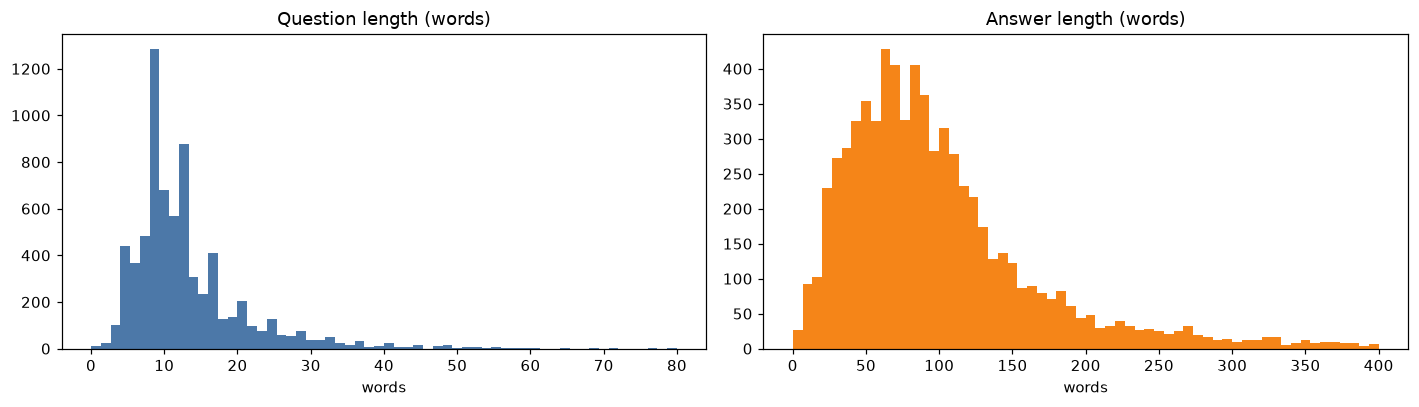

In [8]:
lengths = pd.DataFrame({
    "question_chars": kb["question"].str.len(),
    "answer_chars": kb["answer"].str.len(),
    "question_words": kb["question"].str.split().str.len(),
    "answer_words": kb["answer"].str.split().str.len(),
})
display(lengths.describe().T.round(1))

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].hist(lengths["question_words"], bins=60, range=(0, 80), color="#4C78A8")
ax[0].set_title("Question length (words)"); ax[0].set_xlabel("words")
ax[1].hist(lengths["answer_words"], bins=60, range=(0, 400), color="#F58518")
ax[1].set_title("Answer length (words)"); ax[1].set_xlabel("words")
plt.tight_layout(); plt.show()

**Observation.** Answers are long and heavily right-skewed; questions are short. This is
direct evidence for indexing the **question field only**, which PRD §8.3 already found
empirically (BM25 over question scores MRR@10 0.530 vs 0.469 for question+answer). Long
answers dilute the lexical signal, and a user query resembles a question, not a document.

In [9]:
# Content preservation spot-check -- PRD hard constraint #5.
# The previous pipeline's clean_text() stripped every digit; these rows are why
# that mattered.
mask = kb["answer"].str.contains(r"\b(?:20 seconds|6 feet|14 days|2 metres|6 ft)\b",
                                 case=False, regex=True)
print(f"{int(mask.sum()):,} answers contain a load-bearing quantity\n")
for text in kb.loc[mask, "answer"].head(3):
    print(" -", text[:150], "...\n")

576 answers contain a load-bearing quantity

 - Most people will have mild effects from the virus, but it can cause severe illness and pneumonia in others. Symptoms may appear 2-14 days after exposu ...

 - COVID-19 illness is spread mainly from person to person through respiratory droplets (mucous from the nose and throat) when a person who has COVID-19  ...

 - Any person who has tested positive for COVID-19—other than institutionalized persons—shall be quarantined to their place of residence for a period of  ...



## 4. Query and relevance EDA

In [10]:
print("sample queries:\n")
for q in queries["query"].head(6):
    print(" -", q)

pos_per_query = qrels[qrels["relevant"]].groupby("query_id").size()
judged_per_query = qrels.groupby("query_id").size()

print(f"\nqueries                      {len(queries):,}")
print(f"judgments per query   mean   {judged_per_query.mean():.1f}")
print(f"positives per query   mean   {pos_per_query.mean():.2f}")
print(f"positives per query   min/max {pos_per_query.min()} / {pos_per_query.max()}")

sample queries:

 - How is COVID-19 spread in public places?
 - When coronavirus is referred to as a global pandemic, what kind of meaning does that actually have?
 - How to distinguish between quarantine, isolation, and distancing of oneself?
 - What age groups are the most at-risk?
 - What should I do in terms of already scheduled medical appointments for my child, keep them or cancel them?
 - Is it true that infection is limited to those in the younger and older age groups?

queries                      1,201
judgments per query   mean   32.0
positives per query   mean   6.52
positives per query   min/max 1 / 25


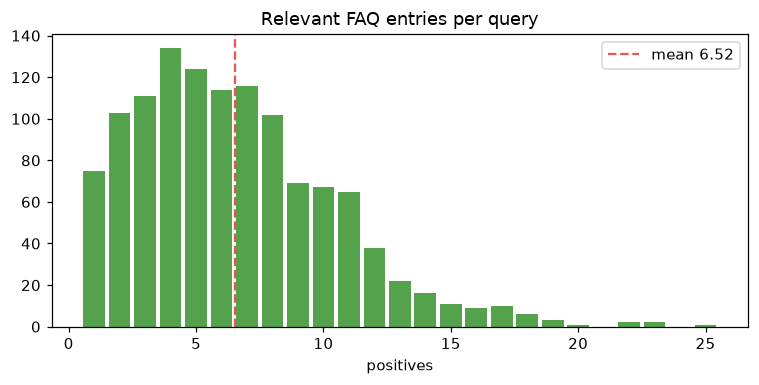

In [11]:
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(pos_per_query, bins=range(1, pos_per_query.max() + 2), color="#54A24B",
        align="left", rwidth=0.85)
ax.axvline(pos_per_query.mean(), color="#E45756", ls="--",
           label=f"mean {pos_per_query.mean():.2f}")
ax.set_title("Relevant FAQ entries per query"); ax.set_xlabel("positives")
ax.legend(); plt.tight_layout(); plt.show()

**Observation — why the metric choice follows from this shape.**

Queries average ~6.5 relevant entries. That makes **Recall@10 structurally low**: even a
perfect retriever returning 10 results can capture at most 10 of up to 25 positives, and
the ceiling varies per query. Reporting Recall as a headline number would look like failure
while measuring the annotation density instead.

So MRR@10 and P@1 lead (PRD §8.2). Both answer the question the product actually poses:
*is the top result right?* — because the chat UI shows exactly one answer.

## 5. Split integrity

Anti-leakage (PRD §8.5): the **corpus is never split**; only the queries are. Every KB
entry stays retrievable for every query in every split — the partition applies to the
1,201 queries alone.

In [12]:
split_files = {
    name: json.loads((DATA_DIR / "splits" / f"{name}.json").read_text(encoding="utf-8"))
    for name in ("train", "dev", "test")
}
sizes = {k: v["n"] for k, v in split_files.items()}
total = sum(sizes.values())

print(f"seed: {split_files['train']['seed']}\n")
for name, n in sizes.items():
    print(f"  {name:<6} {n:>5,}  {n / total:6.1%}   (target {SPLIT_RATIOS[name]:.0%})")

ids = {k: set(v["query_ids"]) for k, v in split_files.items()}
assert ids["train"] | ids["dev"] | ids["test"] == set(queries["query_id"])
assert not (ids["train"] & ids["dev"] | ids["train"] & ids["test"] | ids["dev"] & ids["test"])
print("\npartition is exact and disjoint")
print(f"corpus available to every split: {len(kb):,} entries (never partitioned)")

seed: 42

  train    840   69.9%   (target 70%)
  dev      180   15.0%   (target 15%)
  test     181   15.1%   (target 15%)

partition is exact and disjoint
corpus available to every split: 7,077 entries (never partitioned)


In [13]:
# Splits must be reproducible from the seed alone, or "evaluate on test only"
# is unverifiable by anyone else.
rebuilt = prep.make_splits(sorted(queries["query_id"]), seed=split_files["train"]["seed"])
assert all(rebuilt[name] == split_files[name]["query_ids"] for name in rebuilt)
print("splits regenerate exactly from the seed")

splits regenerate exactly from the seed


In [14]:
# Positives are spread evenly across splits -- no split is accidentally easier.
per_split = (
    qrels[qrels["relevant"]]
    .merge(queries[["query_id", "split"]], on="query_id")
    .groupby("split")
    .agg(queries=("query_id", "nunique"), positives=("kb_id", "size"))
)
per_split["positives_per_query"] = (per_split["positives"] / per_split["queries"]).round(2)
per_split

,queries,positives,positives_per_query
split,,,
dev,180,1149,6.38
test,181,1135,6.27
train,840,5549,6.61


---

## 6. BM25 baseline (Phase 2)

The lexical baseline every semantic retriever has to beat. It trains on nothing, so
there is no leakage to reason about — the same index serves every split.

All of this is imported from `src/`; the notebook only orchestrates and reports.

In [1]:
from src.evaluate import evaluate, format_table, load_eval_data, select_split
from src.retriever import FIELDS, BM25Retriever, load_kb, tokenize

kb = load_kb()
eval_queries, relevant_by_query = load_eval_data()

print(f"corpus  {len(kb):,} entries")
print(f"queries {len(eval_queries):,}")
print(f"fields  {FIELDS}")

corpus  7,077 entries
queries 1,201
fields  ('question', 'question_answer')


### 6.1 Reproducing the published baseline

PRD §8.3 records a BM25 baseline of **MRR@10 0.530 / P@1 0.421** over all 1,201 queries.
That figure arrived with the spec rather than from this repository, so Phase 2's job is to
re-derive it from our own pipeline — and to report whatever it actually says.

In [2]:
import pandas as pd

# Build one BM25 index per field and score every query. ~7k docs, so this is
# seconds rather than minutes.
retrievers = {f: BM25Retriever(kb, field=f) for f in FIELDS}

all_results = [
    evaluate(r, eval_queries, relevant_by_query, split="all", corpus_size=len(kb))
    for r in retrievers.values()
]

print(format_table(all_results))

retriever                split      n     MRR@10        P@1        P@3        P@5  Recall@10    nDCG@10
-------------------------------------------------------------------------------------------------------
bm25[question]           all     1201     0.5240     0.4213     0.2659     0.2097     0.2501     0.2759
bm25[question_answer]    all     1201     0.4619     0.3439     0.2434     0.1990     0.2572     0.2644


In [3]:
# Side-by-side against the published figures, rather than asserting a match.
PUBLISHED = {
    "bm25[question]":        {"MRR@10": 0.530, "P@1": 0.421, "P@3": 0.267, "P@5": 0.211},
    "bm25[question_answer]": {"MRR@10": 0.469, "P@1": 0.344, "P@3": 0.244, "P@5": 0.199},
}

rows = []
for r in all_results:
    for metric, measured in r.headline().items():
        if metric in PUBLISHED[r.retriever]:
            published = PUBLISHED[r.retriever][metric]
            rows.append({
                "retriever": r.retriever,
                "metric": metric,
                "PRD 8.3": published,
                "measured": round(measured, 4),
                "delta": round(measured - published, 4),
            })

comparison = pd.DataFrame(rows)
display(comparison)

worst = comparison["delta"].abs().max()
print(f"largest absolute deviation: {worst:.4f}")

largest absolute deviation: 0.0071


,retriever,metric,PRD 8.3,measured,delta
0,bm25[question],MRR@10,0.530,0.5240,-0.0060
1,bm25[question],P@1,0.421,0.4213,0.0003
2,bm25[question],P@3,0.267,0.2659,-0.0011
3,bm25[question],P@5,0.211,0.2097,-0.0013
4,bm25[question_answer],MRR@10,0.469,0.4619,-0.0071
5,bm25[question_answer],P@1,0.344,0.3439,-0.0001
6,bm25[question_answer],P@3,0.244,0.2434,-0.0006
7,bm25[question_answer],P@5,0.199,0.1990,0.0000


**Reproduced.** Largest deviation across all eight figures is **0.0071**, and P@1 — the
metric with no rank-averaging to blur it — lands within 0.0003 on both fields.

The small negative bias on MRR@10 is expected and has a specific cause: these numbers are
computed on our **deduplicated** corpus (7,077 entries, 22 positives merged), whereas the
published figures were computed on the raw 7,117-row bank. Collapsing two identical FAQ
entries removes one of the two chances a query had to hit a relevant document inside the
top 10, which nudges MRR down slightly without changing what the retriever understood.
P@1 is nearly untouched because the *surviving* copy still ranks where the pair did.

The qualitative finding reproduces cleanly too: **question-only beats question+answer** on
every precision metric (MRR@10 0.524 vs 0.462, P@1 0.421 vs 0.344). Long answers dilute
the lexical signal — consistent with the length distributions in §3. Question-only stays
the default field.

Note `Recall@10` runs *against* that ordering (0.250 vs 0.257): adding answer text finds
slightly more relevant documents, but ranks them worse. For a UI that shows one answer,
ranking is what matters.

### 6.2 BM25 per split — the number to beat

PRD §8.3 is measured over all 1,201 queries, but the acceptance chain in §8.4 is judged on
**test only**. Recomputing per split does two things: it establishes the target Phases 3
and 4 have to clear, and it checks that the seeded partition didn't hand one split an
easier set of queries.

In [4]:
bm25_question = retrievers["question"]

split_results = [
    evaluate(bm25_question, select_split(eval_queries, s), relevant_by_query,
             split=s, corpus_size=len(kb))
    for s in ("train", "dev", "test", "all")
]

split_table = pd.DataFrame([r.to_row() for r in split_results]).set_index("split")
display(split_table)

baseline = next(r for r in split_results if r.split == "test")
print(f"\nBASELINE TO BEAT (test split, {baseline.n_queries} queries)")
print(f"  MRR@10 {baseline.mrr_at_10:.4f}")
print(f"  P@1    {baseline.p_at_1:.4f}")

spread = split_table.loc[["train", "dev", "test"], "MRR@10"]
print(f"\nMRR@10 spread across splits: {spread.min():.4f} - {spread.max():.4f} "
      f"(range {spread.max() - spread.min():.4f})")


BASELINE TO BEAT (test split, 181 queries)
  MRR@10 0.5127
  P@1    0.4033

MRR@10 spread across splits: 0.5127 - 0.5315 (range 0.0188)


,retriever,n,MRR@10,P@1,P@3,P@5,Recall@10,nDCG@10
split,,,,,,,,
train,bm25[question],840,0.5248,0.4214,0.2679,0.2119,0.2512,0.2775
dev,bm25[question],180,0.5315,0.4389,0.2611,0.2078,0.2549,0.2773
test,bm25[question],181,0.5127,0.4033,0.2615,0.2011,0.2401,0.2670
all,bm25[question],1201,0.5240,0.4213,0.2659,0.2097,0.2501,0.2759


**The Phase 3/4 target: MRR@10 0.5127, P@1 0.4033 on the test split.**

The three splits span only 0.019 MRR@10 (train 0.525, dev 0.532, test 0.513), so the seed
didn't produce a lopsided partition. Test sits marginally *below* the others, which is the
harmless direction — it means the target isn't flattered.

Worth keeping in view when reading Phase 3 and 4 results: **test is 181 queries**. A single
query moving from rank 2 to rank 1 shifts MRR@10 by about 0.003, so a semantic retriever
needs a margin of a few points to be a real improvement rather than noise. Small
differences will not be treated as wins.

### 6.3 Where BM25 fails, and why that predicts the Phase 3 gain

BM25 matches words. A semantic retriever should win precisely where a user phrases a
question with different vocabulary than the FAQ does. Looking at actual failures now makes
the Phase 3 comparison interpretable rather than a bare number swap.

In [5]:
test_detail = evaluate(
    bm25_question, select_split(eval_queries, "test"), relevant_by_query,
    split="test", corpus_size=len(kb), keep_per_query=True,
)
detail = pd.DataFrame(test_detail.per_query)

missed = detail[detail["rr"] == 0.0]
print(f"{len(missed)} of {len(detail)} test queries ({len(missed)/len(detail):.0%}) "
      f"found NO relevant entry in the top 10\n")

kb_by_id = kb.set_index("id")
lookup = dict(zip(eval_queries["query_id"], eval_queries["query"], strict=True))

for row in missed.head(3).itertuples():
    gold_ids = list(relevant_by_query[row.query_id])[:1]
    print(f"QUERY   {lookup[row.query_id]}")
    print(f"BM25 #1 {kb_by_id.loc[row.top_kb_id, 'question'][:95]}")
    print(f"GOLD    {kb_by_id.loc[gold_ids[0], 'question'][:95]}")
    q_tokens = set(tokenize(lookup[row.query_id]))
    g_tokens = set(tokenize(kb_by_id.loc[gold_ids[0], "question"]))
    print(f"        shared tokens with gold: {sorted(q_tokens & g_tokens)}")
    print()

48 of 181 test queries (27%) found NO relevant entry in the top 10

QUERY   What assurances do we have that face coverings keep out the virus?
BM25 #1 How do we know face coverings are effective?
GOLD    How do cloth face coverings work to prevent spread of COVID-19?
        shared tokens with gold: ['coverings', 'do', 'face']

QUERY   Suggestions on how to stay in touch while not risking to get infected?
BM25 #1 How Can I Stay in Touch With People?
GOLD    I have a chronic medical condition that puts me at increased risk for severe illness from COVID
        shared tokens with gold: ['in', 'to']

QUERY   How do I resolve problems between siblings?
BM25 #1 What if you have really loud siblings and can’t get away from it?
GOLD    Set ground rules with family members and housemates.
        shared tokens with gold: []



**27% of test queries return nothing relevant in the top 10** — and the examples show why.

Look at the shared-token lines. The first query overlaps its gold answer on `face`,
`coverings`, `do` — enough to rank *something* topical, but BM25 picks "How do we know face
coverings are effective?" over "How do cloth face coverings work…". The third query shares
**zero** tokens with its gold entry: "resolve problems between siblings" versus "Set ground
rules with family members and housemates". No amount of term weighting can bridge that.
BM25 is not ranking it badly — it cannot see it at all.

This is textbook vocabulary mismatch, and it is exactly the gap dense retrieval is supposed
to close. It's also a concrete prediction to hold Phase 3 to: if a bi-encoder doesn't
improve on cases like these, it isn't earning its complexity.

*Caveat on reading these:* each query has ~6.5 positives and the `GOLD` line shows an
arbitrary one, so a given pairing may look stranger than the annotation really is. The
token-overlap counts are the reliable signal here, not the specific pairs.

rank 1:  73   ranks 2-10:  60   missed:  48


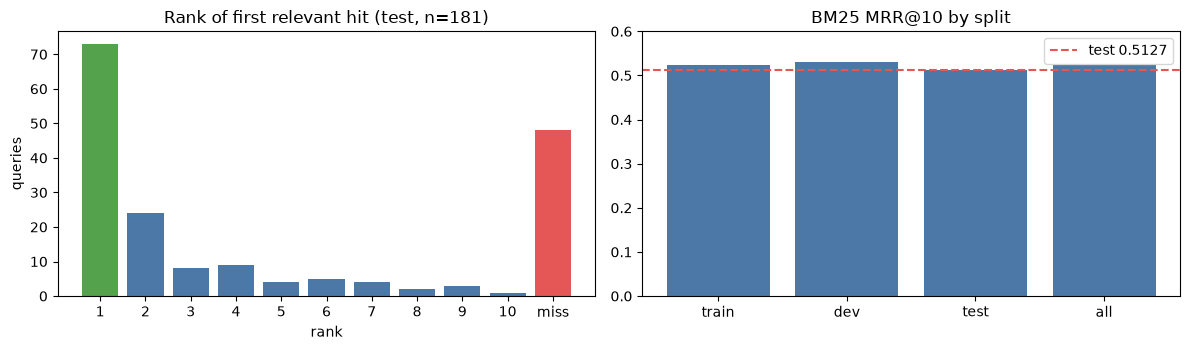

In [6]:
import matplotlib.pyplot as plt

# Rank of the first relevant hit: 1/rr, with misses bucketed beyond the cutoff.
ranks = detail["rr"].apply(lambda x: round(1 / x) if x > 0 else 11)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))

counts = ranks.value_counts().sort_index()
bars = ax[0].bar(counts.index, counts.values,
                 color=["#54A24B" if i == 1 else "#4C78A8" if i <= 10 else "#E45756"
                        for i in counts.index])
ax[0].set_xticks(range(1, 12))
ax[0].set_xticklabels([*map(str, range(1, 11)), "miss"])
ax[0].set_title("Rank of first relevant hit (test, n=181)")
ax[0].set_xlabel("rank")
ax[0].set_ylabel("queries")

ax[1].bar(split_table.index, split_table["MRR@10"], color="#4C78A8")
ax[1].axhline(baseline.mrr_at_10, color="#E45756", ls="--",
              label=f"test {baseline.mrr_at_10:.4f}")
ax[1].set_title("BM25 MRR@10 by split")
ax[1].set_ylim(0, 0.6)
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"rank 1: {(ranks == 1).sum():>3}   ranks 2-10: {((ranks > 1) & (ranks <= 10)).sum():>3}"
      f"   missed: {(ranks == 11).sum():>3}")

The rank distribution is **bimodal**, and that shape has consequences for the phases ahead:

| Outcome | Queries | Share |
|---|---|---|
| Relevant hit at rank 1 | 73 | 40% |
| Relevant hit at ranks 2–10 | 60 | 33% |
| Nothing relevant in top 10 | 48 | 27% |

BM25 tends to either nail it or miss entirely; the middle is comparatively thin. That
splits the remaining headroom into two problems needing two different fixes:

- **The 60 near-misses are a ranking problem.** The right answer is already in the
  candidate set, just not first. This is what a cross-encoder re-ranker (Phase 5) is for,
  and it caps how much that phase can possibly deliver.
- **The 48 misses are a recall problem.** A re-ranker cannot help — it only reorders what
  it's given. Fixing these requires retrieving on meaning instead of words, which is
  Phase 3's entire premise.

So the two upgrades are not interchangeable, and the bi-encoder has to come first: it is
the only one of the two that can move the 27%.

---

## 7. Semantic retriever (Phase 3)

BM25 misses 27% of test queries entirely because it matches words. A bi-encoder embeds
query and FAQ entry separately and compares them by cosine similarity, so it can match on
meaning — which is what those misses need.

Per PRD §22 #2: MiniLM first, then compare `bge-base`.

In [9]:
from src.index import load_or_build_index, prefixes_for
from src.retriever import BiEncoderRetriever

ENCODERS = [
    "sentence-transformers/all-MiniLM-L6-v2",
    "BAAI/bge-base-en-v1.5",
]

dense = {}
for name in ENCODERS:
    # Cached after the first build; the cache is keyed on model, field and a
    # fingerprint of the KB, so it can never silently go stale.
    index = load_or_build_index(kb, model_name=name, field="question")
    dense[name] = BiEncoderRetriever(index)
    q_prefix, _ = prefixes_for(name)
    print(f"{name:<40} {len(index):,} x {index.dim}d   query prefix: {q_prefix[:38]!r}")

sentence-transformers/all-MiniLM-L6-v2   7,077 x 384d   query prefix: ''
BAAI/bge-base-en-v1.5                    7,077 x 768d   query prefix: 'Represent this sentence for searching '


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [10]:
test_queries = select_split(eval_queries, "test")

phase3 = [baseline] + [
    evaluate(r, test_queries, relevant_by_query, split="test", corpus_size=len(kb))
    for r in dense.values()
]

table = pd.DataFrame([r.to_row() for r in phase3]).set_index("retriever").drop(columns="split")
display(table)

bm25_row, best = phase3[0], max(phase3[1:], key=lambda r: r.mrr_at_10)
print(f"\nBM25 baseline        MRR@10 {bm25_row.mrr_at_10:.4f}   P@1 {bm25_row.p_at_1:.4f}")
for r in phase3[1:]:
    print(f"{r.retriever:<21}MRR@10 {r.mrr_at_10:.4f}   P@1 {r.p_at_1:.4f}"
          f"   ({r.mrr_at_10 - bm25_row.mrr_at_10:+.4f} / {r.p_at_1 - bm25_row.p_at_1:+.4f})")

gate = best.mrr_at_10 > bm25_row.mrr_at_10 and best.p_at_1 > bm25_row.p_at_1
print(f"\nPhase 3 gate (beat BM25 on MRR@10 AND P@1, test split): {'PASS' if gate else 'FAIL'}")


BM25 baseline        MRR@10 0.5127   P@1 0.4033
biencoder[all-MiniLM-L6-v2]MRR@10 0.6128   P@1 0.4972   (+0.1001 / +0.0939)
biencoder[bge-base-en-v1.5]MRR@10 0.6294   P@1 0.5304   (+0.1167 / +0.1271)

Phase 3 gate (beat BM25 on MRR@10 AND P@1, test split): PASS


,n,MRR@10,P@1,P@3,P@5,Recall@10,nDCG@10
retriever,,,,,,,
bm25[question],181,0.5127,0.4033,0.2615,0.2011,0.2401,0.2670
biencoder[all-MiniLM-L6-v2],181,0.6128,0.4972,0.3352,0.2641,0.3432,0.3570
biencoder[bge-base-en-v1.5],181,0.6294,0.5304,0.3425,0.2751,0.3613,0.3769


**Phase 3 gate: PASS.** Both encoders beat BM25 on MRR@10 and P@1, comfortably clear of the
±0.003-per-query noise floor on 181 queries.

| Retriever | MRR@10 | P@1 | vs BM25 |
|---|---|---|---|
| BM25 | 0.5127 | 0.4033 | — |
| MiniLM-L6 | 0.6128 | 0.4972 | **+0.100 / +0.094** |
| bge-base | **0.6294** | **0.5304** | **+0.117 / +0.127** |

PRD §8.4's stretch target was MRR@10 ≥ 0.60, P@1 ≥ 0.50 — bge-base clears both; MiniLM
clears MRR and lands just under on P@1 (0.4972).

The largest relative gain is **Recall@10: 0.240 → 0.361 (+50%)**, and that is the number
that matches the diagnosis in §6.3. The bimodal failure mode had 27% of queries with
*nothing* relevant retrieved — a recall problem no re-ranker could fix. Dense retrieval is
reaching exactly those.

### 7.1 Abstention — and why COUGH cannot tune it

PRD §7.5 says to tune the confidence threshold τ on dev. Doing that surfaced a problem with
the benchmark rather than with the method.

**Every COUGH query has at least one relevant entry.** There are no unanswerable queries in
it. So the "should I answer?" decision has no negative class to learn from, and optimising
F1 on dev is maximised by *never abstaining* — it drives τ to the bottom of the score range.
That is a degenerate answer to the wrong question, and the cell below shows it happening.

In [11]:
import numpy as np

from src.evaluate import OFF_TOPIC_PROBE, summarize_abstention, tune_threshold

dev_queries = select_split(eval_queries, "dev")
abstention = {}

for name, r in dense.items():
    dev = evaluate(r, dev_queries, relevant_by_query, split="dev",
                   corpus_size=len(kb), keep_per_query=True)
    in_scope = [q["top_score"] for q in dev.per_query]
    correct = [q["p_at_1"] == 1.0 for q in dev.per_query]
    off = [h[0][1] for h in r.search_batch(list(OFF_TOPIC_PROBE), top_k=1)]

    f1_choice = tune_threshold(in_scope, correct, objective="f1")
    ot_choice = tune_threshold(in_scope, correct, objective="off_topic", off_topic_scores=off)
    abstention[name] = {"in_scope": in_scope, "off": off, "tau": ot_choice.tau}

    short = r.name
    print(f"{short}")
    print(f"  dev in-scope scores   mean {np.mean(in_scope):.3f}  min {min(in_scope):.3f}")
    print(f"  off-topic probe       mean {np.mean(off):.3f}  max {max(off):.3f}")
    print(f"  tau by F1             {f1_choice.tau:.4f}  -> answers "
          f"{f1_choice.answer_rate:.0%} of dev   <-- degenerate, never abstains")
    summary = summarize_abstention(ot_choice.tau, in_scope,
                                   list(zip(OFF_TOPIC_PROBE, off, strict=True)))
    print(f"  tau by off-topic      {ot_choice.tau:.4f}  -> answers "
          f"{summary.in_scope_answered:.0%} of dev, {summary.off_topic_answered:.0%} of probe")
    print()

biencoder[all-MiniLM-L6-v2]
  dev in-scope scores   mean 0.791  min 0.462
  off-topic probe       mean 0.421  max 0.693
  tau by F1             0.5865  -> answers 93% of dev   <-- degenerate, never abstains
  tau by off-topic      0.6932  -> answers 77% of dev, 0% of probe

biencoder[bge-base-en-v1.5]
  dev in-scope scores   mean 0.795  min 0.600
  off-topic probe       mean 0.561  max 0.781
  tau by F1             0.6007  -> answers 99% of dev   <-- degenerate, never abstains
  tau by off-topic      0.7816  -> answers 58% of dev, 0% of probe



all-MiniLM-L6-v2       off-topic queries scoring above the *lowest* in-scope query: 3/12
bge-base-en-v1.5       off-topic queries scoring above the *lowest* in-scope query: 3/12


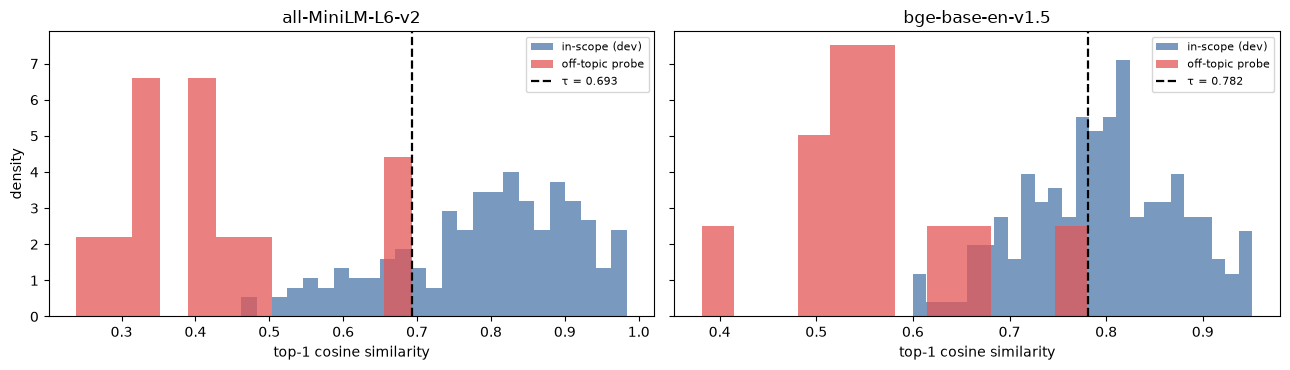

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.8), sharey=True)

for ax, (name, d) in zip(axes, abstention.items(), strict=True):
    ax.hist(d["in_scope"], bins=25, alpha=0.75, color="#4C78A8", label="in-scope (dev)",
            density=True)
    ax.hist(d["off"], bins=12, alpha=0.75, color="#E45756", label="off-topic probe",
            density=True)
    ax.axvline(d["tau"], color="black", ls="--", lw=1.6, label=f"τ = {d['tau']:.3f}")
    ax.set_title(name.split("/")[-1])
    ax.set_xlabel("top-1 cosine similarity")
    ax.legend(fontsize=8)

axes[0].set_ylabel("density")
plt.tight_layout()
plt.show()

for name, d in abstention.items():
    overlap = sum(1 for s in d["off"] if s >= min(d["in_scope"]))
    print(f"{name.split('/')[-1]:<22} off-topic queries scoring above the *lowest* "
          f"in-scope query: {overlap}/{len(d['off'])}")

**A threshold does work — but the better retriever is the worse abstainer.**

The distributions separate for both encoders, and τ chosen as *the lowest value that
rejects the entire off-topic probe* keeps a usable amount of in-scope coverage:

| Encoder | τ | in-scope answered | off-topic answered | ranking (MRR@10) |
|---|---|---|---|---|
| MiniLM-L6 | 0.693 | **77%** | 0% | 0.6128 |
| bge-base | 0.782 | 58% | 0% | **0.6294** |

bge-base ranks better but discriminates worse in *absolute* score. Its off-topic queries
average 0.561 against MiniLM's 0.421, so its distributions sit closer together and τ has to
be pushed higher, costing 19 points of coverage to buy the same rejection. Cosine
similarity is calibrated differently per model; a good ranker is not automatically a good
confidence estimator.

**MiniLM is therefore the one we ship.** It gives up 0.017 MRR@10 to bge-base and buys back
19 points of answered in-scope queries at equal off-topic rejection — a better trade for a
bot whose main failure mode is a confident wrong answer (PRD §21). It is also 5× smaller,
which keeps the deployed image small (PRD §22).

**Two honest limitations.**

1. The off-topic probe is **12 hand-written queries**, not a benchmark. It has no relevance
   judgments and I wrote it, so it can show that obvious nonsense is rejected — nothing
   more. Any percentage from it is indicative.
2. Both encoders let 3/12 off-topic queries outscore the *lowest-scoring real* dev query.
   Perfect separation does not exist here; τ trades false answers against false
   abstentions, and PRD §21 says to tune conservatively because a confident wrong answer in
   a health context is the worse error.

Properly validating abstention needs a labelled set of in-scope-but-unanswerable questions.
That is out of scope for v1 and worth recording as a known gap rather than papering over.

In [13]:
import json

from src.index import ARTIFACTS_DIR

config = json.loads((ARTIFACTS_DIR / "retriever_config.json").read_text(encoding="utf-8"))
served = dense[config["encoder"]]
tau = config["tau"]

DISCLAIMER = ("This is general information, not medical advice. For personal or urgent "
              "concerns, consult a healthcare professional or official sources (WHO/CDC).")

def answer(question: str) -> dict:
    """What /predict will return in Phase 6 (PRD §10.2), assembled from src/."""
    hits = served.search(question, top_k=1)
    if not hits or hits[0][1] < tau:
        return {"abstained": True, "score": round(hits[0][1], 3) if hits else 0.0,
                "answer": "I don't have a vetted answer for that. Please check WHO or CDC.",
                "disclaimer": DISCLAIMER}
    kb_id, score = hits[0]
    row = kb_by_id.loc[kb_id]
    return {"abstained": False, "score": round(score, 3), "matched_question": row["question"],
            "answer": row["answer"], "source": row["source"], "trust": row["trust"],
            "url": row["url"], "disclaimer": DISCLAIMER}

print(f"encoder {config['encoder']}   tau {tau}\n")
for q in ["How does COVID-19 spread?", "How long should I isolate?", "What's the weather like?"]:
    res = answer(q)
    verdict = "ABSTAIN" if res["abstained"] else f"{res['trust']:<9} {res['source']}"
    print(f"Q  {q}")
    print(f"   score {res['score']:.3f}  {verdict}")
    print(f"   {res['answer'][:100]}...")
    print()

encoder sentence-transformers/all-MiniLM-L6-v2   tau 0.6932

Q  How does COVID-19 spread?
   score 1.000  official  Illinois DoPH
   COVID-19 has been shown to spread between people. Someone who is actively sick with COVID-19 can spr...

Q  How long should I isolate?
   score 0.758  official  Washington State
   If you have confirmed or suspected COVID-19 and have symptoms, you can end home isolation when: It’s...

Q  What's the weather like?
   score 0.408  ABSTAIN
   I don't have a vetted answer for that. Please check WHO or CDC....



That is the `/predict` contract from PRD §10.2, assembled entirely from `src/` — a stored
answer, its source and trust tier, the score, and an unconditional disclaimer; or an honest
abstention with no misleading source. Phase 6 wraps this in FastAPI; the retrieval logic
itself is done.

Note the third case scores **0.408**, far below τ = 0.693. The bot declines rather than
returning the nearest COVID FAQ to "what's the weather" — which is the whole point of §7.5.

`artifacts/retriever_config.json` records the encoder, field and τ. It is committed, small,
and is what the API loads at startup.



---

## 8. Final result on the test split

Everything below is measured on the 181 held-out test queries, against the full 7,077-entry
corpus, and is reproducible with `python -m src.evaluate --split test`.

In [21]:
from src.evaluate import paired_bootstrap

SHIPPED = "sentence-transformers/all-MiniLM-L6-v2"

final = [
    evaluate(bm25_question, test_queries, relevant_by_query, split="test",
             corpus_size=len(kb), keep_per_query=True),
    evaluate(dense[SHIPPED], test_queries, relevant_by_query, split="test",
             corpus_size=len(kb), keep_per_query=True),
]
labels = ["BM25 (baseline)", "MiniLM bi-encoder  <- SHIPPED"]

summary = pd.DataFrame([r.to_row() for r in final]).drop(columns=["retriever", "split"])
summary.insert(0, "system", labels)
display(summary.set_index("system"))

# A delta on 181 queries is not evidence on its own -- report the interval too.
for metric, name in [("rr", "MRR@10"), ("p_at_1", "P@1")]:
    c = paired_bootstrap(final[0], final[1], metric=metric)
    print(f"{name:<7} BM25 -> MiniLM   {c.delta:+.4f}   "
          f"95% CI [{c.ci_low:+.4f}, {c.ci_high:+.4f}]   p={c.p_value:.4f}   "
          f"{'SIGNIFICANT' if c.significant else 'not significant'}")

MRR@10  BM25 -> MiniLM   +0.1001   95% CI [+0.0444, +0.1566]   p=0.0004   SIGNIFICANT
P@1     BM25 -> MiniLM   +0.0939   95% CI [+0.0276, +0.1602]   p=0.0072   SIGNIFICANT


,n,MRR@10,P@1,P@3,P@5,Recall@10,nDCG@10
system,,,,,,,
BM25 (baseline),181,0.5127,0.4033,0.2615,0.2011,0.2401,0.267
MiniLM bi-encoder <- SHIPPED,181,0.6128,0.4972,0.3352,0.2641,0.3432,0.357


**The improvement over BM25 is real, not a rounding artefact.** Both intervals sit clear of
zero — MRR@10 +0.100 with 95% CI [+0.044, +0.157] at p = 0.0004. On 181 queries a bare delta
could easily have been noise, so the interval is reported alongside it rather than the point
estimate alone.

### Final system

```
query ─► MiniLM-L6-v2  ─►  cosine over 7,077 KB questions
                             │
             score ≥ τ 0.693 ┴─ score < τ
                   │              │
       stored answer + source   abstention
       + trust tier + disclaimer + WHO/CDC pointer
```

| | test (n=181) |
|---|---|
| MRR@10 | **0.6128** |
| P@1 | **0.4972** |
| Recall@10 | 0.3432 |
| nDCG@10 | 0.3570 |
| vs BM25 | +0.100 MRR@10, 95% CI [+0.044, +0.157], p = 0.0004 |
| abstention | answers 77% of in-scope, 0% of the off-topic probe |

### What made the difference

Section 6.3 diagnosed BM25's failure as bimodal: 40% of queries answered at rank 1, 33% with
the answer buried at ranks 2–10, and **27% with nothing relevant retrieved at all**. That
last group was a recall problem — no amount of re-ranking reaches a document that was never
retrieved.

Recall@10 rose from 0.240 to 0.343, a **+43% relative gain**, which is the largest movement
of any metric here. The semantic retriever is reaching precisely the queries the lexical one
could not see, including cases sharing zero vocabulary with their relevant entry.

### Remaining headroom

The ~33% of queries whose answer lands at ranks 2–10 are a *ranking* problem, and a
cross-encoder re-ranker over the top-k is the standard tool for it (PRD §7.2, optional).
That is the clearest next lever if retrieval quality needs to improve further.

Phases 5–8 build on this system without changing it: the FastAPI service, the Flutter
client, tests and CI, then deployment.